# CMS Medicare IRF – Initial Exploratory Data Analysis

## Practicum Phase 1: Dataset Exploration -- Aug. 24th- Sep. 11th

**Dataset:** CMS Medicare Post-Acute Care Utilization – 
Inpatient Rehabilitation Facility by Geography and Provider

**Purpose:**  
Explore the structure, quality, and characteristics of the CMS IRF dataset 
to identify meaningful patterns and develop potential research questions 
for further analysis.

**Phase 1 Goals:**
- Understand dataset structure and variables
- Identify missing or suppressed data
- Examine provider, state, and national-level records
- Explore utilization, payment, patient, and therapy variables
- Identify patterns or anomalies worth investigating
- Develop candidate research questions

In [2]:
import glob

glob.glob("*.zip")

['Medicare Post-Acute Care Utilization - Inpatient Rehabilitation Facility by Geography and Provider.zip']

In [3]:
import zipfile

zip_file = glob.glob("*.zip")[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("data")

print("Dataset extracted!")

Dataset extracted!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Suppression Handling Helpers

The dataset uses `"*"` as CMS's suppression marker instead of a standard missing value. The next two helper functions consolidate the suppression checks and numeric conversions used repeatedly throughout this notebook, so the same logic doesn't get rewritten for each variable group.

In [5]:
def suppression_summary(data, columns=None):
    """
    Count '*' (CMS suppression marker) per column.
    Returns count + percent suppressed, columns with 0 suppression
    dropped, sorted descending by percent suppressed.
    """
    cols = columns if columns is not None else data.columns
    summary = pd.DataFrame({
        "suppressed_count": (data[cols] == "*").sum(),
        "suppressed_percent": (data[cols] == "*").mean() * 100
    })
    return summary[summary["suppressed_count"] > 0].sort_values(
        "suppressed_percent", ascending=False
    )


def to_numeric_suppressed(data, columns, inplace=False):
    """
    Convert columns to numeric, treating '*' (and any other
    non-numeric values) as NaN via errors='coerce'.
    """
    target = data if inplace else data.copy()
    target[columns] = target[columns].apply(pd.to_numeric, errors="coerce")
    return target

In [6]:
import os

os.listdir("data")

['Medicare Post-Acute Care Utilization - Inpatient Rehabilitation Facility by Geography and Provider']

In [7]:
folder = "data/Medicare Post-Acute Care Utilization - Inpatient Rehabilitation Facility by Geography and Provider"

os.listdir(folder)

['2024']

In [8]:
year_folder = folder + "/2024"    # this is the raw dataset -- extracted from the zip file 

os.listdir(year_folder)

['RY26_PACPUF_IRF_2024_main_S.csv']

In [9]:
# load 
file_path = year_folder + "/RY26_PACPUF_IRF_2024_main_S.csv"

df = pd.read_csv(file_path)

print("Dataset loaded correctly!")
print("Dataset Dimensions:", df.shape)

Dataset loaded correctly!
Dataset Dimensions: (1218, 82)


In [10]:
df.head()

,YEAR,YEAR_TYPE,SMRY_CTGRY,SRVC_CTGRY,PRVDR_ID,PRVDR_NAME,PRVDR_CITY,STATE,PRVDR_ZIP,BENE_DSTNCT_CNT,...,CNCRNT_GRP_PT_MNTS,COTRT_PT_MNTS,TOT_OT_MNTS,INDVDL_OT_MNTS,CNCRNT_GRP_OT_MNTS,COTRT_OT_MNTS,TOT_SLP_MNTS,INDVDL_SLP_MNTS,CNCRNT_GRP_SLP_MNTS,COTRT_SLP_MNTS
0,2024,FY,NATION,IRF,NATIONAL TOTAL,NATIONAL TOTAL,NATIONAL TOTAL,NATIONAL TOTAL,NATIONAL TOTAL,377403,...,36196209,1991748,260369334,224479972,33891770,1997592,59054173,55378653,3509966,165554
1,2024,FY,STATE,IRF,STATE TOTAL,STATE TOTAL,STATE TOTAL,AK,STATE TOTAL,494,...,163,398,277991,277241,0,750,73329,73056,90,183
2,2024,FY,STATE,IRF,STATE TOTAL,STATE TOTAL,STATE TOTAL,AL,STATE TOTAL,6919,...,1416378,41786,5168880,3775367,1352962,40551,1038623,941566,94385,2672
3,2024,FY,STATE,IRF,STATE TOTAL,STATE TOTAL,STATE TOTAL,AR,STATE TOTAL,10185,...,1639315,92258,7824938,6079521,1654635,90782,1735066,1420891,311296,2879
4,2024,FY,STATE,IRF,STATE TOTAL,STATE TOTAL,STATE TOTAL,AZ,STATE TOTAL,10951,...,900914,58202,6031765,5177650,795866,58249,1471926,1336511,134402,1013


## 1. Dataset Structure

The CMS IRF dataset contains 1,218 observations and 82 variables.  
The dataset includes multiple summary levels, including national, state, 
and individual provider records.

Before analysis, the structure and data types will be examined to determine which variables are appropriate for provider level analysis.

In [11]:
# dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 82 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   YEAR                              1218 non-null   int64  
 1   YEAR_TYPE                         1218 non-null   object 
 2   SMRY_CTGRY                        1218 non-null   object 
 3   SRVC_CTGRY                        1218 non-null   object 
 4   PRVDR_ID                          1218 non-null   object 
 5   PRVDR_NAME                        1218 non-null   object 
 6   PRVDR_CITY                        1218 non-null   object 
 7   STATE                             1218 non-null   object 
 8   PRVDR_ZIP                         1218 non-null   object 
 9   BENE_DSTNCT_CNT                   1218 non-null   int64  
 10  TOT_EPSD_STAY_CNT                 1218 non-null   int64  
 11  TOT_SRVC_DAYS                     1218 non-null   int64  
 12  TOT_CH

In [12]:
# Display all column names
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. YEAR
2. YEAR_TYPE
3. SMRY_CTGRY
4. SRVC_CTGRY
5. PRVDR_ID
6. PRVDR_NAME
7. PRVDR_CITY
8. STATE
9. PRVDR_ZIP
10. BENE_DSTNCT_CNT
11. TOT_EPSD_STAY_CNT
12. TOT_SRVC_DAYS
13. TOT_CHRG_AMT
14. TOT_ALOWD_AMT
15. TOT_MDCR_PYMT_AMT
16. TOT_MDCR_STDZD_PYMT_AMT
17. TOT_OUTLIER_PYMT_AMT
18. BENE_DUAL_PCT
19. BENE_RRL_PCT
20. BENE_AVG_AGE
21. BENE_MALE_PCT
22. BENE_FEML_PCT
23. BENE_RACE_WHT_PCT
24. BENE_RACE_BLACK_PCT
25. BENE_RACE_API_PCT
26. BENE_RACE_HSPNC_PCT
27. BENE_RACE_NATIND_PCT
28. BENE_RACE_UNK_PCT
29. BENE_RACE_OTHR_PCT
30. BENE_AVG_RISK_SCRE
31. BENE_CC_BH_ADHD_OTHCD_V1_PCT
32. BENE_CC_BH_ALCOHOL_DRUG_V1_PCT
33. BENE_CC_BH_ALZ_NONALZDEM_V2_PCT
34. BENE_CC_BH_ANXIETY_V1_PCT
35. BENE_CC_BH_BIPOLAR_V1_PCT
36. BENE_CC_BH_DEPRESS_V1_PCT
37. BENE_CC_BH_MOOD_V2_PCT
38. BENE_CC_BH_PD_V1_PCT
39. BENE_CC_BH_PTSD_V1_PCT
40. BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT
41. BENE_CC_BH_TOBACCO_V1_PCT
42. BENE_CC_PH_AFIB_V2_PCT
43. BENE_CC_PH_ARTHRITIS_V2_PCT
44. BENE_CC_PH_ASTHMA_V2_PCT
45. BENE_CC_PH_CANC

In [13]:
df["SMRY_CTGRY"].value_counts() # summary levels

SMRY_CTGRY
PROVIDER    1165
STATE         52
NATION         1
Name: count, dtype: int64

In [14]:
# Count each data type in the dataset
df.dtypes.value_counts()

object     71
int64      10
float64     1
Name: count, dtype: int64

In [15]:
# Check for standard missing values
df.isnull().sum().sort_values(ascending=False).head(20)

YEAR                       0
YEAR_TYPE                  0
SMRY_CTGRY                 0
SRVC_CTGRY                 0
PRVDR_ID                   0
PRVDR_NAME                 0
PRVDR_CITY                 0
STATE                      0
PRVDR_ZIP                  0
BENE_DSTNCT_CNT            0
TOT_EPSD_STAY_CNT          0
TOT_SRVC_DAYS              0
TOT_CHRG_AMT               0
TOT_ALOWD_AMT              0
TOT_MDCR_PYMT_AMT          0
TOT_MDCR_STDZD_PYMT_AMT    0
TOT_OUTLIER_PYMT_AMT       0
BENE_DUAL_PCT              0
BENE_RRL_PCT               0
BENE_AVG_AGE               0
dtype: int64

In [16]:
# Identify non numeric values in columns 

for col in df.select_dtypes(include="object").columns:
    numeric_version = pd.to_numeric(df[col], errors="coerce")
    
    non_numeric = df.loc[
        numeric_version.isna() & df[col].notna(), col
    ].unique()
    
    if len(non_numeric) > 0:
        print(f"{col}: {non_numeric[:10]}")

YEAR_TYPE: ['FY']
SMRY_CTGRY: ['NATION' 'STATE' 'PROVIDER']
SRVC_CTGRY: ['IRF']
PRVDR_ID: ['NATIONAL TOTAL' 'STATE TOTAL']
PRVDR_NAME: ['NATIONAL TOTAL' 'STATE TOTAL' 'Alaska Regional Hospital'
 'St Elias Specialty Hospital' "St Vincent's East"
 'University Of Alabama Hospital' 'Dch Regional Medical Center'
 'Thomas Hospital' 'Grandview Medical Center'
 'Mobile Infirmary Medical Center']
PRVDR_CITY: ['NATIONAL TOTAL' 'STATE TOTAL' 'Anchorage' 'Birmingham' 'Tuscaloosa'
 'Fairhope' 'Mobile' 'Bessemer' 'Vestavia' 'Muscle Shoals']
STATE: ['NATIONAL TOTAL' 'AK' 'AL' 'AR' 'AZ' 'CA' 'CO' 'CT' 'DC' 'DE']
PRVDR_ZIP: ['NATIONAL TOTAL' 'STATE TOTAL']
BENE_DUAL_PCT: ['+' '*']
BENE_RRL_PCT: ['*']
BENE_MALE_PCT: ['*']
BENE_FEML_PCT: ['*']
BENE_RACE_WHT_PCT: ['*']
BENE_RACE_BLACK_PCT: ['*']
BENE_RACE_API_PCT: ['*']
BENE_RACE_HSPNC_PCT: ['*']
BENE_RACE_NATIND_PCT: ['*']
BENE_RACE_UNK_PCT: ['*']
BENE_RACE_OTHR_PCT: ['*']
BENE_CC_BH_ADHD_OTHCD_V1_PCT: ['*']
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT: ['*']
BENE_CC_

In [17]:
# Count asterisk/suppressed values in each column

suppression_summary(df)

,suppressed_count,suppressed_percent
BENE_RACE_UNK_PCT,879,72.167488
BENE_CC_BH_ADHD_OTHCD_V1_PCT,810,66.502463
BENE_RACE_OTHR_PCT,789,64.778325
BENE_CC_BH_PD_V1_PCT,766,62.889984
BENE_CC_BH_PTSD_V1_PCT,743,61.001642
...,...,...
COTRT_OT_MNTS,6,0.492611
TOT_SLP_MNTS,6,0.492611
INDVDL_SLP_MNTS,6,0.492611
CNCRNT_GRP_SLP_MNTS,6,0.492611


In [18]:
# Calculating percentage of suppressed values in each column

suppression_summary(df).head(20)

,suppressed_count,suppressed_percent
BENE_RACE_UNK_PCT,879,72.167488
BENE_CC_BH_ADHD_OTHCD_V1_PCT,810,66.502463
BENE_RACE_OTHR_PCT,789,64.778325
BENE_CC_BH_PD_V1_PCT,766,62.889984
BENE_CC_BH_PTSD_V1_PCT,743,61.001642
BENE_RACE_API_PCT,713,58.538588
PRMRY_DX_NEOBLD_PCT,682,55.993432
BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT,629,51.642036
BENE_RACE_HSPNC_PCT,615,50.492611
PRMRY_DX_RSPSYSTM_PCT,596,48.932677


### Initial Data Quality Findings

The dataset contains 71 variables stored as object data types, although many
represent percentages, utilization measures, or other numeric values.

Standard missing value analysis identified no NaN values. However, further
inspection identified asterisks (`*`) within 63 variables, indicating that
missing or suppressed information is represented differently from standard
null values.

The amount of suppression varies substantially across variables. Several
beneficiary demographic, behavioral health, and diagnosis variables have
high levels of suppression, with some exceeding 50% of observations.
Other variables, including several therapy utilization measures, contain
relatively little suppression.

The meaning of the CMS suppression indicator and the extent of suppression
will need to be considered when selecting variables for further analysis.
No suppressed values have been modified during this initial exploration.

## 2. Provider-Level Exploration

The dataset contains national, state, and individual provider summary records.
Because the primary unit of interest for provider level pattern discovery is
the individual inpatient rehabilitation facility, provider records will be
examined separately from state and national aggregate records.

The original dataframe (`df`) will remain unchanged during this exploration.

In [19]:
# Creating a provider level dataframe seperately 
providers = df[df["SMRY_CTGRY"] == "PROVIDER"].copy()

print("Provider-level dimensions:", providers.shape)

Provider-level dimensions: (1165, 82)


In [20]:
# IRF providers by state
providers["STATE"].value_counts()

STATE
TX    145
FL     81
CA     77
PA     64
LA     58
OH     50
IL     40
MI     39
NY     37
IN     36
MO     32
GA     31
TN     29
SC     27
AR     26
VA     26
OK     25
WI     23
NC     22
AZ     21
CO     21
KS     21
AL     18
KY     18
IA     17
WA     13
NJ     13
MA     12
UT     11
MN     11
NV     11
MS     10
NE      9
NM      8
OR      8
WV      8
PR      8
ID      7
CT      7
DE      5
SD      5
RI      5
NH      5
MT      4
ND      4
ME      4
WY      3
MD      3
AK      2
DC      2
VT      2
HI      1
Name: count, dtype: int64

In [21]:
# Overview of provider level records
providers[
    [
        "PRVDR_ID",
        "PRVDR_NAME",
        "PRVDR_CITY",
        "STATE",
        "BENE_DSTNCT_CNT",
        "TOT_EPSD_STAY_CNT",
        "TOT_SRVC_DAYS",
        "TOT_MDCR_PYMT_AMT"
    ]
].head(10)

,PRVDR_ID,PRVDR_NAME,PRVDR_CITY,STATE,BENE_DSTNCT_CNT,TOT_EPSD_STAY_CNT,TOT_SRVC_DAYS,TOT_MDCR_PYMT_AMT
53,020017,Alaska Regional Hospital,Anchorage,AK,120,122,1619,3894224
54,022001,St Elias Specialty Hospital,Anchorage,AK,375,388,5717,12775485
55,010011,St Vincent's East,Birmingham,AL,46,48,713,981729
56,010033,University Of Alabama Hospital,Birmingham,AL,151,164,2264,4509372
57,010092,Dch Regional Medical Center,Tuscaloosa,AL,243,263,3887,5786466
58,010100,Thomas Hospital,Fairhope,AL,90,90,1484,2340601
59,010104,Grandview Medical Center,Birmingham,AL,172,193,2229,3908934
60,010113,Mobile Infirmary Medical Center,Mobile,AL,93,99,2138,2311049
61,010114,"Medical West, An Affiliate Of Uab Health System",Bessemer,AL,55,60,819,1437186
62,010139,Brookwood Baptist Medical Center,Vestavia,AL,274,296,3655,6306805


## 3. Provider Utilization and Payment Exploration 

Initial provider   level exploration will examine differences in facility volume,
service utilization, and Medicare payments.

The purpose of this analysis is to identify the overall distribution of these
measures and determine whether substantial variation exists across IRF providers.
These observations may help identify patterns and develop potential research
questions for further analysis.

In [22]:
# Core provider utilization and payment variables
core_vars = [
    "BENE_DSTNCT_CNT",
    "TOT_EPSD_STAY_CNT",
    "TOT_SRVC_DAYS",
    "TOT_CHRG_AMT",
    "TOT_ALOWD_AMT",
    "TOT_MDCR_PYMT_AMT",
    "TOT_MDCR_STDZD_PYMT_AMT",
    "TOT_OUTLIER_PYMT_AMT",
    "BENE_AVG_AGE",
    "BENE_AVG_RISK_SCRE"
]

providers[core_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
BENE_DSTNCT_CNT,1165.0,3.351116e+02,3.278035e+02,11.00,117.00,209.00,455.00,2.947000e+03
TOT_EPSD_STAY_CNT,1165.0,3.731837e+02,3.755861e+02,11.00,125.00,221.00,503.00,3.305000e+03
TOT_SRVC_DAYS,1165.0,4.590951e+03,4.621655e+03,137.00,1529.00,2771.00,6334.00,4.367800e+04
TOT_CHRG_AMT,1165.0,2.142233e+07,2.577592e+07,224752.00,7286979.00,14672813.00,27390210.00,3.742799e+08
TOT_ALOWD_AMT,1165.0,9.459792e+06,9.613663e+06,165747.00,3076625.00,5833028.00,13206338.00,9.925966e+07
TOT_MDCR_PYMT_AMT,1165.0,9.289370e+06,9.418089e+06,161619.00,3034772.00,5761628.00,12954396.00,9.758301e+07
TOT_MDCR_STDZD_PYMT_AMT,1165.0,9.266730e+06,9.128799e+06,271105.00,3145899.00,5676481.00,12861917.00,8.191882e+07
TOT_OUTLIER_PYMT_AMT,1165.0,3.100659e+05,7.713997e+05,0.00,14389.00,77218.00,279819.00,9.939920e+06
BENE_AVG_AGE,1165.0,7.721717e+01,2.266228e+00,63.00,76.00,78.00,79.00,8.300000e+01
BENE_AVG_RISK_SCRE,1165.0,2.408807e+00,4.474501e-01,0.89,2.14,2.39,2.64,5.220000e+00


In [61]:
# editing by how long a patient stay is? 

providers["DAYS_PER_STAY"] = (
    providers["TOT_SRVC_DAYS"] /
    providers["TOT_EPSD_STAY_CNT"]
)

providers["MDCR_PYMT_PER_STAY"] = (
    providers["TOT_MDCR_PYMT_AMT"] /
    providers["TOT_EPSD_STAY_CNT"]
)

providers["CHRG_PER_STAY"] = (
    providers["TOT_CHRG_AMT"] /
    providers["TOT_EPSD_STAY_CNT"]
)

In [25]:
providers[
    [
        "DAYS_PER_STAY",
        "MDCR_PYMT_PER_STAY",
        "CHRG_PER_STAY"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
DAYS_PER_STAY,1165.0,12.444793,1.650336,8.153846,11.436170,12.245150,13.266272,22.888889
MDCR_PYMT_PER_STAY,1165.0,25685.807799,6768.805714,10101.187500,21808.430380,23954.221239,27184.858824,79672.328283
CHRG_PER_STAY,1165.0,66427.932089,41543.916142,14131.987179,36493.736842,53098.638191,81518.413534,314725.373206


In [26]:
# Providers with highest Medicare payment per stay

providers[
    [
        "PRVDR_NAME",
        "PRVDR_CITY",
        "STATE",
        "TOT_EPSD_STAY_CNT",
        "BENE_AVG_RISK_SCRE",
        "DAYS_PER_STAY",
        "MDCR_PYMT_PER_STAY"
    ]
].sort_values(
    "MDCR_PYMT_PER_STAY",
    ascending=False
).head(10)

,PRVDR_NAME,PRVDR_CITY,STATE,TOT_EPSD_STAY_CNT,BENE_AVG_RISK_SCRE,DAYS_PER_STAY,MDCR_PYMT_PER_STAY
126,Santa Clara Valley Medical Center,San Jose,CA,198,1.90,17.944444,79672.328283
179,Lac/rancho Los Amigos National Rehabilitation ...,Downey,CA,127,2.27,17.228346,67749.047244
144,Saint Francis Memorial Hospital,San Francisco,CA,54,2.39,15.333333,65999.574074
746,Staten Island University Hospital,Staten Island,NY,193,2.16,12.678756,64602.010363
133,Kaiser Foundation Hospital And Rehab Center,Vallejo,CA,18,1.19,16.944444,61217.111111
244,Hca Florida Jfk Hospital,Atlantis,FL,269,2.58,12.992565,60169.609665
761,Suny Health Science Center At Brooklyn University,Brooklyn,NY,36,3.15,13.944444,56161.027778
125,Grossmont Hospital,La Mesa,CA,73,1.69,16.000000,55445.397260
148,Providence Santa Rosa Memorial Hospital,Santa Rosa,CA,130,2.18,13.907692,54245.715385
143,Community Hospital Of The Monterey Peninsula,Monterey,CA,147,2.45,14.217687,53291.782313


In [27]:
# Providers with lowest Medicare payment per stay

providers[
    [
        "PRVDR_NAME",
        "PRVDR_CITY",
        "STATE",
        "TOT_EPSD_STAY_CNT",
        "BENE_AVG_RISK_SCRE",
        "DAYS_PER_STAY",
        "MDCR_PYMT_PER_STAY"
    ]
].sort_values(
    "MDCR_PYMT_PER_STAY"
).head(10)

,PRVDR_NAME,PRVDR_CITY,STATE,TOT_EPSD_STAY_CNT,BENE_AVG_RISK_SCRE,DAYS_PER_STAY,MDCR_PYMT_PER_STAY
913,Hospital Oncologico Dr Isaac Gonzalez Martinez,San Juan,PR,16,1.23,11.125000,10101.187500
915,Auxilio Mutuo Hospital,San Juan,PR,78,1.53,8.153846,10177.551282
920,Multy Medical Facilities Corporation,San Juan,PR,41,1.27,11.487805,12787.268293
916,Hospital De La Concepcion,San German,PR,48,1.26,10.062500,13079.437500
917,Hospital Menonita Caguas Inc,Caguas,PR,37,1.10,11.864865,13989.567568
918,Encompass Health Rehabilitation Hospital Of Sa...,San Juan,PR,68,1.97,11.823529,13997.514706
919,Encompass Health Rehabilitation Hospital Manati,Alts De Manati,PR,123,1.70,11.918699,14254.081301
914,Bella Vista Hospital,Mayaguez,PR,11,2.17,12.636364,14808.272727
630,University Of Missouri Health Care,Columbia,MO,90,1.70,8.744444,15998.777778
617,Capital Region Medical Center,Jefferson City,MO,39,2.71,8.743590,16054.820513


In [28]:
# Seeing Facility X being unusually high payment per stay, does not automatically mean "FRAUD" it means this facility is 
# exhibiting a pattern that differs from other providers and may warrant more investigation

### Initial Provider Level Observations

Substantial variation exists across IRF providers in facility volume, total
Medicare payments, and charges. Provider distributions appear right-skewed,
with several large facilities substantially exceeding the median utilization
and payment levels.

After adjusting measures by the number of stays, considerable variation remains.
Median Medicare payment per stay is approximately $24,000. 

The observed provider values range from as low as ($10,000 - $80,000) per stay.
Charges per stay demonstrate even greater variation. 

Initial examination of providers at the highest and lowest ends of Medicare
payment per stay also suggests possible geographic patterns. Several high payment
providers are located in California, while several of the lowest payment
providers are located in Puerto Rico.

These observations do not indicate inappropriate billing or fraud. Geographic
payment differences, patient complexity, length of stay, facility characteristics,
case mix, and other factors may explain some of the observed variation. Further
analysis is needed before provider level differences can be interpreted.

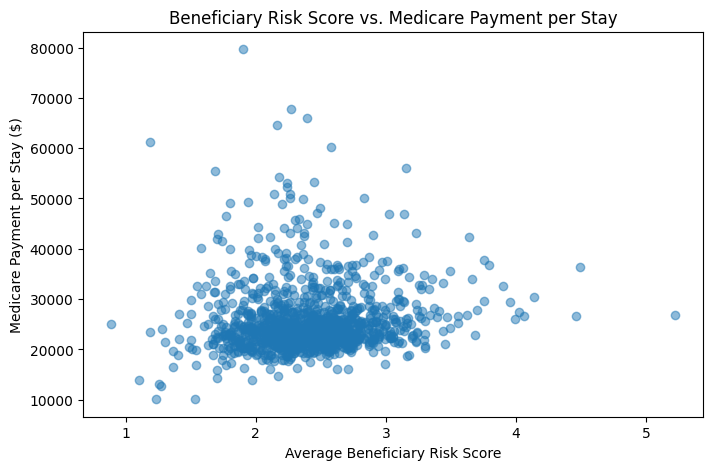

In [29]:
# Relationship between patient risk and Medicare payment per stay

plt.figure(figsize=(8, 5))

plt.scatter(
    providers["BENE_AVG_RISK_SCRE"],
    providers["MDCR_PYMT_PER_STAY"],
    alpha=0.5
)

plt.xlabel("Average Beneficiary Risk Score")
plt.ylabel("Medicare Payment per Stay ($)")
plt.title("Beneficiary Risk Score vs. Medicare Payment per Stay")

plt.show()

** NOTE-- I didn't know this information 

A beneficiary risk score is essentially a measure of the expected healthcare needs/costs of the Medicare patients treated by that provider, based on patient characteristics and diagnoses. In very simple terms:

Higher risk score = a patient population expected to require more healthcare resources.

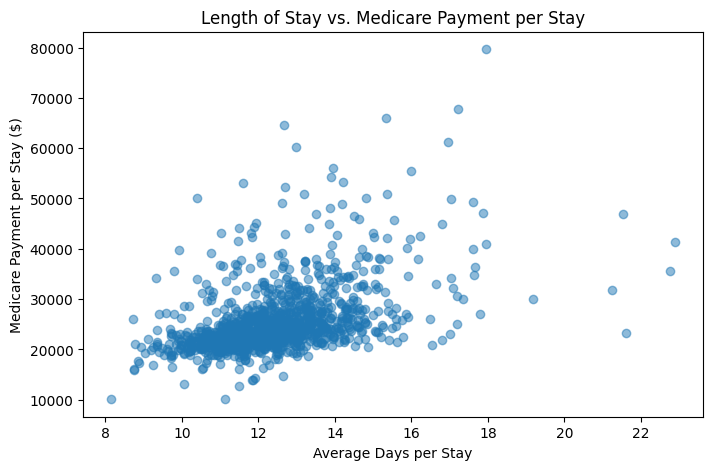

In [30]:
# Relationship between length of stay and Medicare payment per stay

plt.figure(figsize=(8, 5))

plt.scatter(
    providers["DAYS_PER_STAY"],
    providers["MDCR_PYMT_PER_STAY"],
    alpha=0.5
)

plt.xlabel("Average Days per Stay")
plt.ylabel("Medicare Payment per Stay ($)")
plt.title("Length of Stay vs. Medicare Payment per Stay")

plt.show()

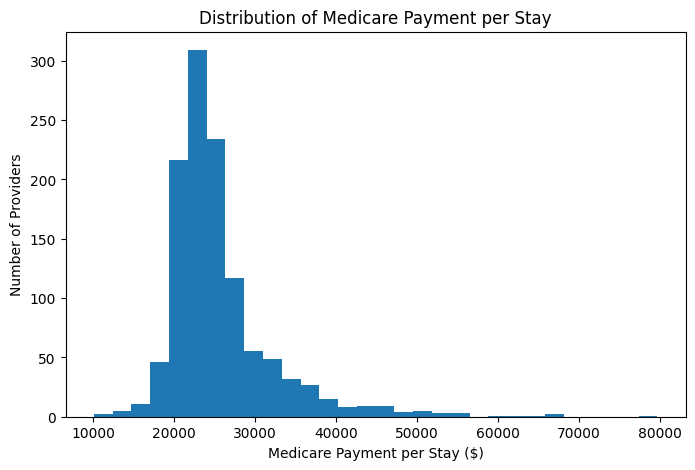

In [31]:
# Distribution of Medicare payment per stay

plt.figure(figsize=(8, 5))

plt.hist(
    providers["MDCR_PYMT_PER_STAY"],
    bins=30
)

plt.xlabel("Medicare Payment per Stay ($)")
plt.ylabel("Number of Providers")
plt.title("Distribution of Medicare Payment per Stay")

plt.show()

### Initial Findings: Medicare Payment per Stay

Exploratory analysis shows substantial variation in Medicare payment per stay across IRF providers.
 
- Beneficiary risk score does not appear to have a strong relationship with Medicare payment per stay. Several high payment providers have risk scores within the typical provider range.
- Average length of stay appears to have a positive relationship with Medicare payment per stay, although considerable variation remains among providers with similar lengths of stay.
- Medicare payment per stay is right-skewed. Most providers are concentrated around lower payment levels, while a smaller number of providers have substantially higher payments.
- These findings suggest that beneficiary risk and length of stay alone may not explain the observed variation in Medicare payments.

The high payment providers warrant further investigation to determine whether factors such as geography, patient characteristics, diagnosis mix, therapy utilization, or outlier payments may help explain these differences.

In [32]:
# Correlation with Medicare payment per stay

providers[
    [
        "MDCR_PYMT_PER_STAY",
        "DAYS_PER_STAY",
        "BENE_AVG_RISK_SCRE"
    ]
].corr()

,MDCR_PYMT_PER_STAY,DAYS_PER_STAY,BENE_AVG_RISK_SCRE
MDCR_PYMT_PER_STAY,1.000000,0.465286,0.078754
DAYS_PER_STAY,0.465286,1.000000,0.099866
BENE_AVG_RISK_SCRE,0.078754,0.099866,1.000000


### Correlation Analysis

Medicare payment per stay had a moderate positive correlation with
average length of stay (r = 0.465), indicating that providers with
longer stays tend to have higher Medicare payments per stay.

Beneficiary risk score had only a very weak correlation with Medicare
payment per stay (r = 0.079) and with average length of stay (r = 0.100).

These results suggest that length of stay explains some of the variation
in Medicare payment per stay, while beneficiary risk score alone does
not appear to explain the large differences observed between providers.
Other provider, geographic, clinical, or payment-related factors may
contribute to the remaining variation.

## 4. Geographic Variation in Medicare Payment

Initial provider level exploration showed substantial variation in Medicare
payment per stay. Providers at the highest and lowest ends of the payment
distribution also appeared to show geographic clustering.

This section explores whether Medicare payment per stay varies systematically
across geographic areas. Regional differences may explain some apparent provider
level outliers.

In [33]:
# Summary of Medicare payment per stay by state

state_payment = (
    providers.groupby("STATE")["MDCR_PYMT_PER_STAY"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

state_payment.round(2)

,count,mean,median,min,max
STATE,,,,,
CA,77,38690.80,35923.04,24767.10,79672.33
NY,37,36168.85,34444.73,19542.85,64602.01
AK,2,32423.19,32423.19,31919.87,32926.51
VT,2,32183.27,32183.27,31669.23,32697.31
OR,8,31551.79,31411.12,25715.97,36617.78
WA,13,30114.16,30952.51,21047.78,40098.09
HI,1,29273.92,29273.92,29273.92,29273.92
MN,11,28680.36,28260.91,19915.08,39041.08
NV,11,27483.02,28176.31,20334.84,32534.14


In [34]:
# States with the highest median Medicare payment per stay

state_payment.head(10)

,count,mean,median,min,max
STATE,,,,,
CA,77,38690.803933,35923.042056,24767.097222,79672.328283
NY,37,36168.852554,34444.731034,19542.845528,64602.010363
AK,2,32423.188292,32423.188292,31919.868852,32926.507732
VT,2,32183.269231,32183.269231,31669.230769,32697.307692
OR,8,31551.790741,31411.116595,25715.966667,36617.783784
WA,13,30114.156856,30952.511013,21047.784000,40098.092105
HI,1,29273.924198,29273.924198,29273.924198,29273.924198
MN,11,28680.357693,28260.913580,19915.082192,39041.083650
NV,11,27483.017033,28176.310225,20334.843373,32534.141361


In [35]:
# States with the lowest median Medicare payment per stay

state_payment.tail(10)

,count,mean,median,min,max
STATE,,,,,
SC,27,22565.904338,22028.000000,19627.163347,28278.296774
LA,58,22177.777602,21813.123059,17353.723529,31820.293651
IA,17,21469.551373,21350.634426,18838.929577,25043.062500
AL,18,21895.272690,21257.352246,17628.075893,27496.170732
ND,4,20982.482368,20926.729868,19271.376712,22805.093023
TN,29,21126.854851,20830.229333,17482.310924,26375.884956
SD,5,20910.141253,20820.553665,18980.210117,22374.341085
WV,8,21339.013658,20682.962059,16063.113636,33590.591837
AR,26,20616.475343,20556.421147,16946.987654,23182.019337


Question: Are these geographic differences still there when we use CMS's standardized Medicare payment codes? 2 codes for payments; 
TOT_MDCR_PYMT_AMT
TOT_MDCR_STDZD_PYMT_AMT

In [36]:
# lets compare the 2 

# Standardized Medicare payment per stay

providers["STDZD_MDCR_PYMT_PER_STAY"] = (
    providers["TOT_MDCR_STDZD_PYMT_AMT"] /
    providers["TOT_EPSD_STAY_CNT"]
)

# Compare actual vs standardized payment by state
state_comparison = (
    providers.groupby("STATE")
    .agg(
        provider_count=("PRVDR_ID", "count"),
        median_actual_payment=("MDCR_PYMT_PER_STAY", "median"),
        median_standardized_payment=("STDZD_MDCR_PYMT_PER_STAY", "median")
    )
    .sort_values("median_actual_payment", ascending=False)
)

state_comparison.round(2)

,provider_count,median_actual_payment,median_standardized_payment
STATE,,,
CA,77,35923.04,26351.75
NY,37,34444.73,26677.47
AK,2,32423.19,28069.31
VT,2,32183.27,31909.76
OR,8,31411.12,26124.62
WA,13,30952.51,25280.32
HI,1,29273.92,22301.43
MN,11,28260.91,25393.72
NV,11,28176.31,23820.27


### Geographic Payment Variation

Medicare payment per stay varies substantially across geographic areas when
using actual Medicare payments. However, these differences become considerably
smaller when standardized Medicare payments are examined.

For example, California had a median actual payment of approximately 35,923 dollars
per stay, compared with a standardized median of approximately 26,352 dollars.
Puerto Rico showed the opposite pattern, with a median actual payment of
approximately 13,535 dollars per stay, compared with a standardized median of
approximately 25,325 dollars.

This suggests that some of the geographic variation observed in actual Medicare
payments may be related to factors accounted for in CMS payment standardization.
Therefore, geographic and payment-system effects should be considered before
interpreting unusually high or low provider payments as provider level anomalies.

### From an Industry standpoint, 

how do we make sense of all these codes and what they mean? Why did the Numbers jump so drastically when standardizing payments were analyzed? how are those numbers standardized? what are the rules or guidelines and how are those adjusted? and compared to what? 


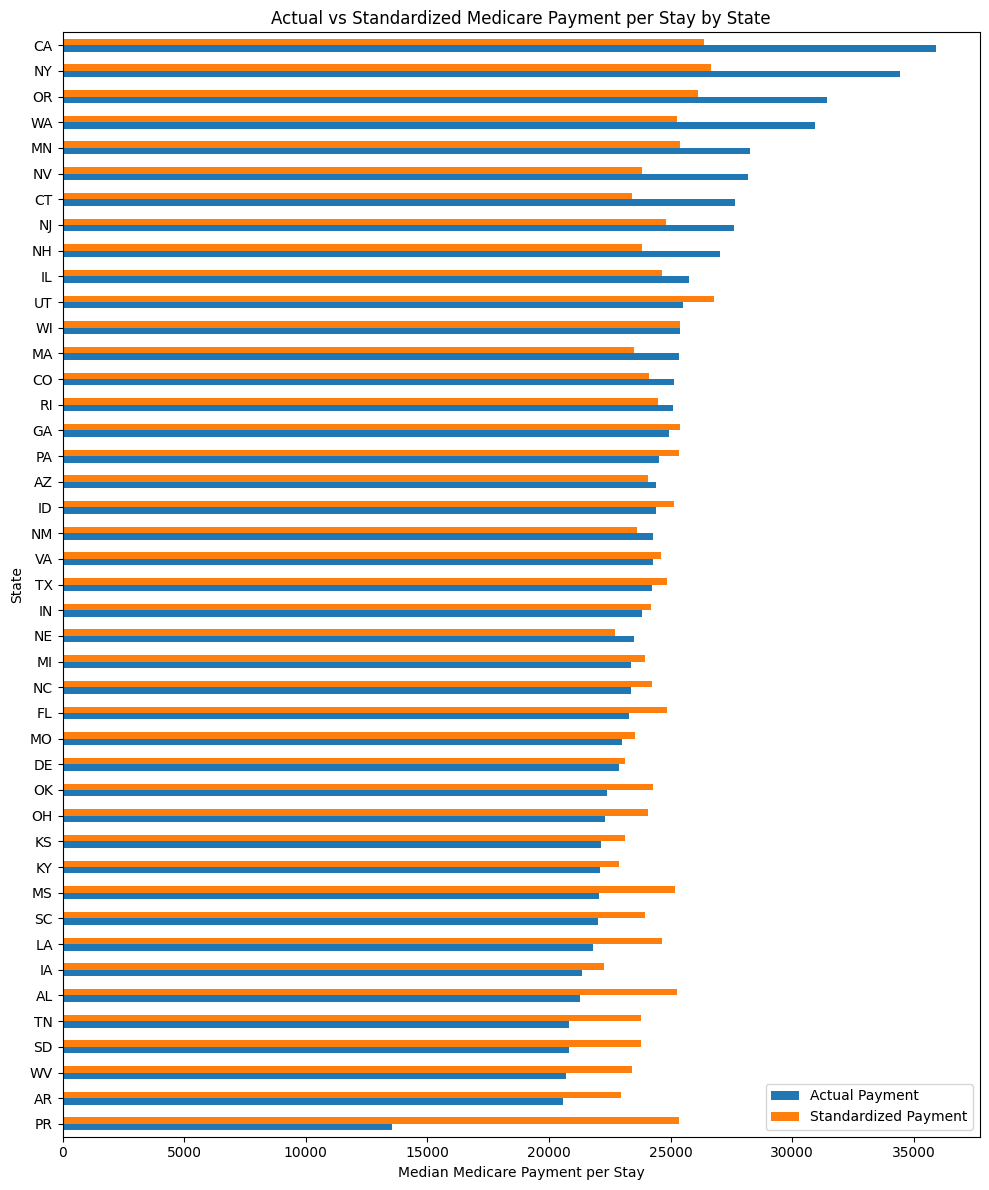

In [37]:
# Keep states with at least 5 providers
state_plot = state_comparison[
    state_comparison["provider_count"] >= 5
].copy()

# Sort by actual Medicare payment
state_plot = state_plot.sort_values(
    "median_actual_payment",
    ascending=True
)

# Plot actual vs standardized median payment per stay
state_plot[
    ["median_actual_payment", "median_standardized_payment"]
].plot(
    kind="barh",
    figsize=(10, 12)
)

plt.xlabel("Median Medicare Payment per Stay")
plt.ylabel("State")
plt.title("Actual vs Standardized Medicare Payment per Stay by State")
plt.legend(["Actual Payment", "Standardized Payment"])
plt.tight_layout()
plt.show()

### Interpretation

Actual Medicare payment per stay varies considerably across states. After
standardization, many of these differences become smaller, suggesting that
some geographic variation in actual payments may reflect Medicare payment
adjustments rather than provider level differences alone.

## 5. Diagnosis and Patient Characteristics

The next step is to explore whether differences in patient populations may help
explain the variation observed across IRF providers. Main question: Could differences in patient populations 
help explain the provider/payment variation we're seeing?

In [38]:
# Identify primary diagnosis variables

diagnosis_cols = [
    col for col in providers.columns
    if col.startswith("PRMRY_DX")
]

print("Number of diagnosis variables:", len(diagnosis_cols))

diagnosis_cols

Number of diagnosis variables: 15


['PRMRY_DX_INFCTN_PCT',
 'PRMRY_DX_NEOBLD_PCT',
 'PRMRY_DX_ENDONUTRMET_PCT',
 'PRMRY_DX_MNTBEHNEUDIS_PCT',
 'PRMRY_DX_NERVSYSTM_PCT',
 'PRMRY_DX_ENTSYS_PCT',
 'PRMRY_DX_CIRCSYSTM_PCT',
 'PRMRY_DX_RSPSYSTM_PCT',
 'PRMRY_DX_DIGSYSTM_PCT',
 'PRMRY_DX_SKNMUSSYSTM_PCT',
 'PRMRY_DX_GUSYSTM_PCT',
 'PRMRY_DX_PRGPERICONG_PCT',
 'PRMRY_DX_SXILLDEF_PCT',
 'PRMRY_DX_INJPOIS_PCT',
 'PRMRY_DX_HLTHSRV_PCT']

In [39]:
# Check suppression in primary diagnosis variables ( we already know theres * lurking everywhere causing problems)

suppression_summary(providers, diagnosis_cols).sort_values("suppressed_percent")

,suppressed_count,suppressed_percent
PRMRY_DX_CIRCSYSTM_PCT,75,6.437768
PRMRY_DX_INJPOIS_PCT,93,7.982833
PRMRY_DX_PRGPERICONG_PCT,95,8.154506
PRMRY_DX_ENTSYS_PCT,149,12.789700
PRMRY_DX_HLTHSRV_PCT,202,17.339056
PRMRY_DX_SXILLDEF_PCT,239,20.515021
PRMRY_DX_MNTBEHNEUDIS_PCT,250,21.459227
PRMRY_DX_NERVSYSTM_PCT,288,24.721030
PRMRY_DX_GUSYSTM_PCT,388,33.304721
PRMRY_DX_INFCTN_PCT,490,42.060086


In [40]:
# Select diagnosis variables with lower suppression -- We are treating * as 0 or NaN because information wasn't given

selected_diagnoses = [
    "PRMRY_DX_CIRCSYSTM_PCT",
    "PRMRY_DX_INJPOIS_PCT",
    "PRMRY_DX_PRGPERICONG_PCT",
    "PRMRY_DX_ENTSYS_PCT"
]

# Convert values to numeric
# Suppressed "*" values will become NaN rather than zero
providers = to_numeric_suppressed(providers, selected_diagnoses, inplace=True)

# Summarize
providers[selected_diagnoses].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
PRMRY_DX_CIRCSYSTM_PCT,1090.0,21.12,10.19,0.0,14.0,19.0,26.0,71.0
PRMRY_DX_INJPOIS_PCT,1072.0,25.02,8.31,0.0,20.0,25.0,30.0,69.0
PRMRY_DX_PRGPERICONG_PCT,1070.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
PRMRY_DX_ENTSYS_PCT,1016.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0


In [41]:
# notice two rows of data mean nothing for all diagnosis 

In [42]:
# Convert all diagnosis variables to numeric
# "*" values become NaN
diagnosis_numeric = to_numeric_suppressed(providers, diagnosis_cols)[diagnosis_cols]

# mean, median, variation, and available data
diagnosis_summary = pd.DataFrame({
    "available_count": diagnosis_numeric.count(),
    "mean_pct": diagnosis_numeric.mean(),
    "median_pct": diagnosis_numeric.median(),
    "std_dev": diagnosis_numeric.std()
})

diagnosis_summary = diagnosis_summary.sort_values(
    "mean_pct",
    ascending=False
)

diagnosis_summary.round(2)

,available_count,mean_pct,median_pct,std_dev
PRMRY_DX_INJPOIS_PCT,1072,25.02,25.0,8.31
PRMRY_DX_CIRCSYSTM_PCT,1090,21.12,19.0,10.19
PRMRY_DX_SXILLDEF_PCT,926,18.29,16.0,11.83
PRMRY_DX_NERVSYSTM_PCT,877,17.55,15.0,11.42
PRMRY_DX_HLTHSRV_PCT,963,16.66,15.0,10.15
PRMRY_DX_SKNMUSSYSTM_PCT,632,6.09,5.0,5.44
PRMRY_DX_RSPSYSTM_PCT,580,1.04,0.0,2.62
PRMRY_DX_NEOBLD_PCT,496,0.27,0.0,1.10
PRMRY_DX_INFCTN_PCT,675,0.11,0.0,0.75
PRMRY_DX_GUSYSTM_PCT,777,0.08,0.0,0.49


In [43]:
# Select the most informative diagnosis categories from above

diagnosis_focus = [
    "PRMRY_DX_INJPOIS_PCT",
    "PRMRY_DX_CIRCSYSTM_PCT",
    "PRMRY_DX_SXILLDEF_PCT",
    "PRMRY_DX_NERVSYSTM_PCT",
    "PRMRY_DX_HLTHSRV_PCT"
]

# Convert selected diagnosis columns to numeric
# Suppressed values remain NaN
providers = to_numeric_suppressed(providers, diagnosis_focus, inplace=True)

# Correlation with standardized Medicare payment per stay

diagnosis_payment_corr = (
    providers[
        diagnosis_focus + ["STDZD_MDCR_PYMT_PER_STAY"]
    ]
    .corr()["STDZD_MDCR_PYMT_PER_STAY"]
    .drop("STDZD_MDCR_PYMT_PER_STAY")
    .sort_values(ascending=False)
)

diagnosis_payment_corr.round(3)

PRMRY_DX_CIRCSYSTM_PCT    0.224
PRMRY_DX_INJPOIS_PCT      0.036
PRMRY_DX_HLTHSRV_PCT      0.029
PRMRY_DX_SXILLDEF_PCT     0.016
PRMRY_DX_NERVSYSTM_PCT   -0.091
Name: STDZD_MDCR_PYMT_PER_STAY, dtype: float64

### Question: 

As the percentage of a provider's patients in a particular DIAGNOSIS category increases, does standardized Medicare payment per stay tend to increase or decrease? Remember we are stil in the exploratory phase, not causation and solving the puzzle 

### Answer: 
none of these diagnosis categories has a strong relationship with payment by itself. This is showing us more of a linear relationship between each diagnosis category and standardized Medicare payment per stay.

In [44]:
# Show all beneficiary related columns in the dataset

bene_cols = [
    col for col in providers.columns
    if col.startswith("BENE_")
]

bene_cols

['BENE_DSTNCT_CNT',
 'BENE_DUAL_PCT',
 'BENE_RRL_PCT',
 'BENE_AVG_AGE',
 'BENE_MALE_PCT',
 'BENE_FEML_PCT',
 'BENE_RACE_WHT_PCT',
 'BENE_RACE_BLACK_PCT',
 'BENE_RACE_API_PCT',
 'BENE_RACE_HSPNC_PCT',
 'BENE_RACE_NATIND_PCT',
 'BENE_RACE_UNK_PCT',
 'BENE_RACE_OTHR_PCT',
 'BENE_AVG_RISK_SCRE',
 'BENE_CC_BH_ADHD_OTHCD_V1_PCT',
 'BENE_CC_BH_ALCOHOL_DRUG_V1_PCT',
 'BENE_CC_BH_ALZ_NONALZDEM_V2_PCT',
 'BENE_CC_BH_ANXIETY_V1_PCT',
 'BENE_CC_BH_BIPOLAR_V1_PCT',
 'BENE_CC_BH_DEPRESS_V1_PCT',
 'BENE_CC_BH_MOOD_V2_PCT',
 'BENE_CC_BH_PD_V1_PCT',
 'BENE_CC_BH_PTSD_V1_PCT',
 'BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT',
 'BENE_CC_BH_TOBACCO_V1_PCT',
 'BENE_CC_PH_AFIB_V2_PCT',
 'BENE_CC_PH_ARTHRITIS_V2_PCT',
 'BENE_CC_PH_ASTHMA_V2_PCT',
 'BENE_CC_PH_CANCER6_V2_PCT',
 'BENE_CC_PH_CKD_V2_PCT',
 'BENE_CC_PH_COPD_V2_PCT',
 'BENE_CC_PH_DIABETES_V2_PCT',
 'BENE_CC_PH_HF_NONIHD_V2_PCT',
 'BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT',
 'BENE_CC_PH_HYPERTENSION_V2_PCT',
 'BENE_CC_PH_ISCHEMICHEART_V2_PCT',
 'BENE_CC_PH_OSTEOPOROSIS_

In [45]:
# Beneficiary demographic and patient characteristic variables

patient_cols = [
    "BENE_DUAL_PCT",
    "BENE_RRL_PCT",
    "BENE_AVG_AGE",
    "BENE_MALE_PCT",
    "BENE_FEML_PCT",
    "BENE_RACE_WHT_PCT",
    "BENE_RACE_BLACK_PCT",
    "BENE_RACE_API_PCT",
    "BENE_RACE_HSPNC_PCT",
    "BENE_RACE_NATIND_PCT",
    "BENE_RACE_UNK_PCT",
    "BENE_RACE_OTHR_PCT",
    "BENE_AVG_RISK_SCRE"
]

# Check suppression for patient characteristics
suppression_summary(providers, patient_cols).sort_values("suppressed_percent")

,suppressed_count,suppressed_percent
BENE_RACE_WHT_PCT,19,1.630901
BENE_MALE_PCT,23,1.974249
BENE_FEML_PCT,23,1.974249
BENE_DUAL_PCT,168,14.420601
BENE_RACE_NATIND_PCT,334,28.669528
BENE_RACE_BLACK_PCT,451,38.712446
BENE_RRL_PCT,499,42.832618
BENE_RACE_HSPNC_PCT,612,52.532189
BENE_RACE_API_PCT,702,60.257511
BENE_RACE_OTHR_PCT,759,65.150215


In [46]:
# Select patient characteristics with lower suppression

patient_focus = [
    "BENE_AVG_AGE",
    "BENE_AVG_RISK_SCRE",
    "BENE_DUAL_PCT",
    "BENE_MALE_PCT",
    "BENE_FEML_PCT",
    "BENE_RACE_WHT_PCT"
]

# Convert selected variables to numeric
# Suppressed values become NaN
providers = to_numeric_suppressed(providers, patient_focus, inplace=True)

# Correlation with standardized Medicare payment per stay

patient_payment_corr = (
    providers[
        patient_focus + ["STDZD_MDCR_PYMT_PER_STAY"]
    ]
    .corr()["STDZD_MDCR_PYMT_PER_STAY"]
    .drop("STDZD_MDCR_PYMT_PER_STAY")
    .sort_values(ascending=False)
)

patient_payment_corr.round(3)

BENE_DUAL_PCT         0.156
BENE_MALE_PCT         0.156
BENE_AVG_RISK_SCRE    0.076
BENE_FEML_PCT        -0.156
BENE_RACE_WHT_PCT    -0.158
BENE_AVG_AGE         -0.197
Name: STDZD_MDCR_PYMT_PER_STAY, dtype: float64

## 6. Therapy Utilization

How does therapy utilization vary across IRF providers, and is therapy utilization
associated with standardized Medicare payment per stay or average length of stay?

### Analysis Plan

This section will examine:

- Physical therapy (PT) utilization
- Occupational therapy (OT) utilization
- Speech-language pathology (SLP) utilization
- Variation in therapy use across providers
- Relationships between therapy utilization, standardized Medicare payment per stay,
  and average length of stay

In [47]:
# Let's see what columns we are working with here

therapy_cols = [
    col for col in providers.columns
    if any(term in col.upper() for term in ["PT_", "OT_", "SLP_"])
]

therapy_cols

['TOT_EPSD_STAY_CNT',
 'TOT_SRVC_DAYS',
 'TOT_CHRG_AMT',
 'TOT_ALOWD_AMT',
 'TOT_MDCR_PYMT_AMT',
 'TOT_MDCR_STDZD_PYMT_AMT',
 'TOT_OUTLIER_PYMT_AMT',
 'TOT_PT_MNTS',
 'INDVDL_PT_MNTS',
 'CNCRNT_GRP_PT_MNTS',
 'COTRT_PT_MNTS',
 'TOT_OT_MNTS',
 'INDVDL_OT_MNTS',
 'CNCRNT_GRP_OT_MNTS',
 'COTRT_OT_MNTS',
 'TOT_SLP_MNTS',
 'INDVDL_SLP_MNTS',
 'CNCRNT_GRP_SLP_MNTS',
 'COTRT_SLP_MNTS']

In [48]:
# Define therapy variables

therapy_cols = [
    "TOT_PT_MNTS",
    "INDVDL_PT_MNTS",
    "CNCRNT_GRP_PT_MNTS",
    "COTRT_PT_MNTS",
    "TOT_OT_MNTS",
    "INDVDL_OT_MNTS",
    "CNCRNT_GRP_OT_MNTS",
    "COTRT_OT_MNTS",
    "TOT_SLP_MNTS",
    "INDVDL_SLP_MNTS",
    "CNCRNT_GRP_SLP_MNTS",
    "COTRT_SLP_MNTS"
]

# Check CMS suppression
suppression_summary(providers, therapy_cols)

,suppressed_count,suppressed_percent
TOT_PT_MNTS,6,0.515021
INDVDL_PT_MNTS,6,0.515021
CNCRNT_GRP_PT_MNTS,6,0.515021
COTRT_PT_MNTS,6,0.515021
TOT_OT_MNTS,6,0.515021
INDVDL_OT_MNTS,6,0.515021
CNCRNT_GRP_OT_MNTS,6,0.515021
COTRT_OT_MNTS,6,0.515021
TOT_SLP_MNTS,6,0.515021
INDVDL_SLP_MNTS,6,0.515021


### Therapy Variable Suppression

Therapy utilization variables have very low suppression. Each PT, OT, and SLP
variable contains only 6 suppressed provider observations, representing approximately
0.5% of providers. Therefore, therapy utilization data are largely complete and
appropriate for further exploratory analysis.

In [49]:
# Converting to numeric
therapy_cols = [
    "TOT_PT_MNTS",
    "INDVDL_PT_MNTS",
    "CNCRNT_GRP_PT_MNTS",
    "COTRT_PT_MNTS",
    "TOT_OT_MNTS",
    "INDVDL_OT_MNTS",
    "CNCRNT_GRP_OT_MNTS",
    "COTRT_OT_MNTS",
    "TOT_SLP_MNTS",
    "INDVDL_SLP_MNTS",
    "CNCRNT_GRP_SLP_MNTS",
    "COTRT_SLP_MNTS"
]

therapy_data = to_numeric_suppressed(
    providers,
    therapy_cols,
    inplace=False
)

therapy_data[therapy_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
TOT_PT_MNTS,1159.0,225705.06,230230.82,6821.0,68282.5,130909.0,310039.0,1558125.0
INDVDL_PT_MNTS,1159.0,192757.04,183088.03,5624.0,64988.0,122943.0,268252.0,1491246.0
CNCRNT_GRP_PT_MNTS,1159.0,31229.52,64713.52,0.0,0.0,1280.0,24578.0,530417.0
COTRT_PT_MNTS,1159.0,1718.51,5058.67,0.0,0.0,55.0,904.0,80945.0
TOT_OT_MNTS,1159.0,224613.23,234818.10,6090.0,69173.0,129330.0,308903.0,1614430.0
INDVDL_OT_MNTS,1159.0,193649.22,187892.81,5927.0,63843.5,122689.0,267634.0,1382112.0
CNCRNT_GRP_OT_MNTS,1159.0,29240.46,62659.78,0.0,0.0,1536.0,23752.0,548198.0
COTRT_OT_MNTS,1159.0,1723.55,5115.21,0.0,0.0,45.0,911.5,83402.0
TOT_SLP_MNTS,1159.0,50938.62,56790.73,30.0,13006.0,31131.0,70847.5,550874.0
INDVDL_SLP_MNTS,1159.0,47767.34,51936.54,0.0,12941.0,30430.0,65570.0,529986.0


In [51]:
# Calculating therapy minutes per stay

therapy_data["PT_MNTS_PER_STAY"] = (
    therapy_data["TOT_PT_MNTS"] / therapy_data["TOT_EPSD_STAY_CNT"]
)

therapy_data["OT_MNTS_PER_STAY"] = (
    therapy_data["TOT_OT_MNTS"] / therapy_data["TOT_EPSD_STAY_CNT"]
)

therapy_data["SLP_MNTS_PER_STAY"] = (
    therapy_data["TOT_SLP_MNTS"] / therapy_data["TOT_EPSD_STAY_CNT"]
)

therapy_per_stay = [
    "PT_MNTS_PER_STAY",
    "OT_MNTS_PER_STAY",
    "SLP_MNTS_PER_STAY"
]

therapy_data[therapy_per_stay].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
PT_MNTS_PER_STAY,1159.0,597.71,135.91,37.80,535.73,616.41,684.41,1072.76
OT_MNTS_PER_STAY,1159.0,591.39,137.18,36.75,527.43,613.66,678.68,967.43
SLP_MNTS_PER_STAY,1159.0,141.83,81.24,1.15,83.27,128.04,187.94,616.81


### Therapy Utilization per Stay – Initial Findings

Therapy utilization was normalized by the number of stays to allow comparisons between providers of different sizes.

Median therapy utilization was approximately 616 minutes per stay for physical therapy (PT), 614 minutes per stay for occupational therapy (OT), and 128 minutes per stay for speech-language pathology (SLP).

PT and OT utilization were very similar across the typical provider, while SLP utilization was substantially lower. 

This raises an important exploratory question: Are differences in therapy utilization associated with Medicare payment per stay, length of stay, patient characteristics, or diagnosis mix?

In [54]:
[col for col in providers.columns if "PER_STAY" in col]

['DAYS_PER_STAY',
 'MDCR_PYMT_PER_STAY',
 'CHRG_PER_STAY',
 'STDZD_MDCR_PYMT_PER_STAY']

In [55]:
# this was moved somehow from the dataframe structure under providers. Lets fix this real quick. 

providers["PT_MNTS_PER_STAY"] = (
    pd.to_numeric(providers["TOT_PT_MNTS"], errors="coerce")
    / providers["TOT_EPSD_STAY_CNT"]
)

providers["OT_MNTS_PER_STAY"] = (
    pd.to_numeric(providers["TOT_OT_MNTS"], errors="coerce")
    / providers["TOT_EPSD_STAY_CNT"]
)

providers["SLP_MNTS_PER_STAY"] = (
    pd.to_numeric(providers["TOT_SLP_MNTS"], errors="coerce")
    / providers["TOT_EPSD_STAY_CNT"]
)

# Check
[col for col in providers.columns if "PER_STAY" in col]

['DAYS_PER_STAY',
 'MDCR_PYMT_PER_STAY',
 'CHRG_PER_STAY',
 'STDZD_MDCR_PYMT_PER_STAY',
 'PT_MNTS_PER_STAY',
 'OT_MNTS_PER_STAY',
 'SLP_MNTS_PER_STAY']

In [56]:
# correlation

therapy_corr_cols = [
    "STDZD_MDCR_PYMT_PER_STAY",
    "DAYS_PER_STAY",
    "PT_MNTS_PER_STAY",
    "OT_MNTS_PER_STAY",
    "SLP_MNTS_PER_STAY"
]

therapy_corr = providers[therapy_corr_cols].corr()

therapy_corr.round(3)

,STDZD_MDCR_PYMT_PER_STAY,DAYS_PER_STAY,PT_MNTS_PER_STAY,OT_MNTS_PER_STAY,SLP_MNTS_PER_STAY
STDZD_MDCR_PYMT_PER_STAY,1.000,0.473,-0.006,-0.012,0.100
DAYS_PER_STAY,0.473,1.000,0.127,0.136,0.227
PT_MNTS_PER_STAY,-0.006,0.127,1.000,0.890,0.110
OT_MNTS_PER_STAY,-0.012,0.136,0.890,1.000,0.125
SLP_MNTS_PER_STAY,0.100,0.227,0.110,0.125,1.000


### Therapy Utilization Findings

Therapy minutes showed little relationship with standardized Medicare payment per stay. PT (r = -0.006) and OT (r = -0.012) showed essentially no correlation, while SLP showed only a weak correlation (r = 0.100).

Length of stay had a stronger relationship with payment (r = 0.473). PT and OT were highly correlated with each other (r = 0.890), which may be important when selecting variables for later modeling.

## 7. Provider Level Variation and Potential Outliers

After accounting for basic utilization patterns, which IRF providers show unusually high or low Medicare payment per stay?

This section will explore provider level variation using standardized Medicare payment per stay. Standardized payment is used to reduce the influence of geographic and payment system differences identified earlier.

The goal is to identify unusual patterns that may warrant further investigation, not to classify providers as fraudulent.....yet

### IQR method

Refresh on this method was needed. My understanding is that Q1= 25 percentile, Q3= 75 percentile so, IQR is Q3-Q1 giving us a representation of the middle 50% of data. You can see outliers using this method or take note of things that are abnormally high or low. 

In [57]:
payment = providers["STDZD_MDCR_PYMT_PER_STAY"]

Q1 = payment.quantile(0.25)
Q3 = payment.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower outlier boundary:", round(lower_bound, 2))
print("Upper outlier boundary:", round(upper_bound, 2))

payment_outliers = providers[
    (providers["STDZD_MDCR_PYMT_PER_STAY"] < lower_bound) |
    (providers["STDZD_MDCR_PYMT_PER_STAY"] > upper_bound)
].copy()

print("\nNumber of potential outlier providers:", len(payment_outliers))
print(
    "Percent of providers:",
    round((len(payment_outliers) / len(providers)) * 100, 1),
    "%"
)

Q1: 23203.83
Q3: 26414.32
IQR: 3210.49
Lower outlier boundary: 18388.09
Upper outlier boundary: 31230.06

Number of potential outlier providers: 84
Percent of providers: 7.2 %


### IQR Outlier Results

Using the IQR method, standardized Medicare payment per stay outside approximately 18,388 dollars to 31,230 dollars was identified as a potential outlier. A total of 84 providers (7.2%) were flagged.

These providers are not necessarily inappropriate or fraudulent. The outlier flag identifies providers with unusual payment patterns that may warrant further investigation using utilization, patient, diagnosis, geographic, and provider characteristics.

In [58]:
# seperate high and low IQR outliers

high_outliers = providers[
    providers["STDZD_MDCR_PYMT_PER_STAY"] > upper_bound
].copy()

low_outliers = providers[
    providers["STDZD_MDCR_PYMT_PER_STAY"] < lower_bound
].copy()

print("High-payment outliers:", len(high_outliers))
print("Low-payment outliers:", len(low_outliers))

# Display the high-payment outliers
high_outliers[
    [
        "PRVDR_NAME",
        "STATE",
        "TOT_EPSD_STAY_CNT",
        "BENE_AVG_RISK_SCRE",
        "DAYS_PER_STAY",
        "STDZD_MDCR_PYMT_PER_STAY"
    ]
].sort_values(
    "STDZD_MDCR_PYMT_PER_STAY",
    ascending=False
).head(15)

High-payment outliers: 83
Low-payment outliers: 1


,PRVDR_NAME,STATE,TOT_EPSD_STAY_CNT,BENE_AVG_RISK_SCRE,DAYS_PER_STAY,STDZD_MDCR_PYMT_PER_STAY
244,Hca Florida Jfk Hospital,FL,269,2.58,12.992565,64822.598513
1038,Rio Grande Regional Hospital,TX,71,3.02,13.507042,57449.352113
1037,Longview Regional Medical Center,TX,143,2.24,11.601399,55530.174825
179,Lac/rancho Los Amigos National Rehabilitation ...,CA,127,2.27,17.228346,53854.677165
746,Staten Island University Hospital,NY,193,2.16,12.678756,51013.098446
250,Hca Florida Aventura Hospital,FL,286,2.60,11.947552,48051.003497
557,Northern Light A R Gould Hospital,ME,23,2.02,15.347826,47837.347826
879,Mercy Catholic Medical Center- Mercy Fitzgerald,PA,66,2.26,10.393939,46627.015152
126,Santa Clara Valley Medical Center,CA,198,1.90,17.944444,46088.030303
125,Grossmont Hospital,CA,73,1.69,16.000000,45473.452055


In [59]:
# low payment outliers

low_outliers[
    [
        "PRVDR_NAME",
        "STATE",
        "TOT_EPSD_STAY_CNT",
        "BENE_AVG_RISK_SCRE",
        "DAYS_PER_STAY",
        "STDZD_MDCR_PYMT_PER_STAY"
    ]
].sort_values(
    "STDZD_MDCR_PYMT_PER_STAY"
)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,PRVDR_NAME,STATE,TOT_EPSD_STAY_CNT,BENE_AVG_RISK_SCRE,DAYS_PER_STAY,STDZD_MDCR_PYMT_PER_STAY
627,Missouri Delta Medical Center,MO,58,2.14,9.706897,18330.896552


In [60]:
# how do the high outliers vary from everyone else? 

providers["HIGH_PAYMENT_OUTLIER"] = (
    providers["STDZD_MDCR_PYMT_PER_STAY"] > upper_bound
)

comparison_vars = [
    "STDZD_MDCR_PYMT_PER_STAY",
    "DAYS_PER_STAY",
    "BENE_AVG_RISK_SCRE",
    "TOT_EPSD_STAY_CNT",
    "PT_MNTS_PER_STAY",
    "OT_MNTS_PER_STAY",
    "SLP_MNTS_PER_STAY"
]

outlier_comparison = (
    providers.groupby("HIGH_PAYMENT_OUTLIER")[comparison_vars]
    .median()
    .T
)

outlier_comparison.columns = ["Other_Providers", "High_Payment_Outliers"]

outlier_comparison.round(2)

,Other_Providers,High_Payment_Outliers
STDZD_MDCR_PYMT_PER_STAY,24383.22,34921.66
DAYS_PER_STAY,12.17,13.94
BENE_AVG_RISK_SCRE,2.39,2.36
TOT_EPSD_STAY_CNT,237.50,130.00
PT_MNTS_PER_STAY,617.15,612.50
OT_MNTS_PER_STAY,615.35,596.69
SLP_MNTS_PER_STAY,126.57,145.58


### High Payment Outlier Comparison

High payment outliers had longer median stays (13.94 vs. 12.17 days) and
lower provider volume (130 vs. 238 stays) than other providers.

Beneficiary risk scores and PT/OT therapy utilization were similar between
groups. This suggests that high standardized payments are not clearly explained
by patient risk or therapy intensity alone. Length of stay and provider volume
may warrant further investigation.

Further analysis should evaluate whether diagnosis mix or other provider characteristics help explain the remaining variation among high payment outliers.

## 8. Phase 1 Synthesis and Research Question Development

### Goal

Use the exploratory findings from the CMS IRF dataset to identify a focused,
testable research question for the next phase of the practicum.

The analysis so far suggests that standardized Medicare payment varies
substantially across IRF providers. Length of stay appears more strongly related
to payment than beneficiary risk score or therapy intensity, while a subset of
providers demonstrates unusually high standardized payments that are not fully
explained by the variables explored so far.

### Key Phase 1 Findings

- Standardized Medicare payment per stay varies substantially across providers.
- Length of stay has a moderate positive relationship with standardized payment.
- Beneficiary risk score has little relationship with standardized payment.
- PT and OT therapy intensity show essentially no relationship with standardized payment.
- Geographic differences decrease substantially after payment standardization.
- IQR analysis identified 84 potential payment outliers, including 83 high-payment providers.
- High-payment outliers tend to have longer stays and lower provider volume, while risk scores and PT/OT utilization are similar to other providers.

### Next Question

What factors help explain unusually high standardized Medicare payment per stay among inpatient rehabilitation facilities?

### Jorie Butler feedback-- 09/17/26 
Identify outliers by type? Look into charactersitics of outliers. Provider level descriptives. Link more data from the same hospital. Report type of facility? Rural? average income for that city. Inpatient facilities (SNF) nursing home? are some of those providers SNF's? 

## 8. High Payment Outlier Characterization

### Question for myself 

What provider, utilization, patient, and facility characteristics distinguish IRF providers with unusually high standardized Medicare payment per stay?

The previous analysis identified 83 providers with standardized Medicare payment
per stay above the IQR upper boundary. These providers will now be examined in
detail to determine whether they share characteristics that may help
explain their unusually high payment patterns.

This analysis will begin with characteristics already available in the CMS IRF
dataset. Additional provider level and geographic information may then be linked
from external datasets when needed.

Potential characteristics to investigate include:

- Provider location and geographic patterns
- Provider volume
- Average length of stay
- Beneficiary risk
- Therapy utilization
- Diagnosis mix
- Facility or provider type
- Rural versus urban location
- Socioeconomic characteristics of the surrounding area

The purpose of this analysis is to characterize unusual provider patterns and
identify potential explanatory factors. 

In [62]:
# Creating master table of high payment outlier providers

outlier_master = providers.loc[
    providers["HIGH_PAYMENT_OUTLIER"],
    [
        "PRVDR_ID",
        "PRVDR_NAME",
        "PRVDR_CITY",
        "STATE",
        "PRVDR_ZIP",
        "TOT_EPSD_STAY_CNT",
        "STDZD_MDCR_PYMT_PER_STAY",
        "DAYS_PER_STAY",
        "BENE_AVG_RISK_SCRE",
        "PT_MNTS_PER_STAY",
        "OT_MNTS_PER_STAY",
        "SLP_MNTS_PER_STAY"
    ]
].copy()

# Sort from highest to lowest standardized payment per stay
outlier_master = outlier_master.sort_values(
    "STDZD_MDCR_PYMT_PER_STAY",
    ascending=False
)

print("Number of high-payment outliers:", len(outlier_master))

outlier_master.head(15)

Number of high-payment outliers: 83


,PRVDR_ID,PRVDR_NAME,PRVDR_CITY,STATE,PRVDR_ZIP,TOT_EPSD_STAY_CNT,STDZD_MDCR_PYMT_PER_STAY,DAYS_PER_STAY,BENE_AVG_RISK_SCRE,PT_MNTS_PER_STAY,OT_MNTS_PER_STAY,SLP_MNTS_PER_STAY
244,100080,Hca Florida Jfk Hospital,Atlantis,FL,33462,269,64822.598513,12.992565,2.58,606.379182,604.338290,45.687732
1038,450711,Rio Grande Regional Hospital,Mcallen,TX,78503,71,57449.352113,13.507042,3.02,336.126761,342.338028,191.408451
1037,450702,Longview Regional Medical Center,Longview,TX,75605,143,55530.174825,11.601399,2.24,719.664336,729.643357,58.734266
179,050717,Lac/rancho Los Amigos National Rehabilitation ...,Downey,CA,90242,127,53854.677165,17.228346,2.27,369.944882,393.566929,3.307087
746,330160,Staten Island University Hospital,Staten Island,NY,10305,193,51013.098446,12.678756,2.16,461.088083,464.844560,61.269430
250,100131,Hca Florida Aventura Hospital,Aventura,FL,33180,286,48051.003497,11.947552,2.60,544.076923,554.391608,107.772727
557,200018,Northern Light A R Gould Hospital,Presque Isle,ME,04769,23,47837.347826,15.347826,2.02,459.521739,455.347826,209.608696
879,390156,Mercy Catholic Medical Center- Mercy Fitzgerald,Darby,PA,19023,66,46627.015152,10.393939,2.26,626.818182,589.696970,88.409091
126,050038,Santa Clara Valley Medical Center,San Jose,CA,95128,198,46088.030303,17.944444,1.90,568.762626,430.656566,223.292929
125,050026,Grossmont Hospital,La Mesa,CA,91942,73,45473.452055,16.000000,1.69,603.178082,586.753425,351.246575


In [63]:
# Descriptive stats for high payment outlier providers

outlier_descriptives = outlier_master[
    [
        "TOT_EPSD_STAY_CNT",
        "STDZD_MDCR_PYMT_PER_STAY",
        "DAYS_PER_STAY",
        "BENE_AVG_RISK_SCRE",
        "PT_MNTS_PER_STAY",
        "OT_MNTS_PER_STAY",
        "SLP_MNTS_PER_STAY"
    ]
].describe().T

outlier_descriptives.round(2)

,count,mean,std,min,25%,50%,75%,max
TOT_EPSD_STAY_CNT,83.0,162.31,133.90,18.00,73.00,130.00,211.50,826.00
STDZD_MDCR_PYMT_PER_STAY,83.0,37581.49,6636.84,31336.74,33088.24,34921.66,39924.51,64822.60
DAYS_PER_STAY,83.0,14.41,2.61,9.80,12.67,13.94,15.37,22.89
BENE_AVG_RISK_SCRE,83.0,2.38,0.46,1.19,2.08,2.36,2.63,3.66
PT_MNTS_PER_STAY,82.0,585.47,153.00,140.31,491.24,612.50,690.22,834.91
OT_MNTS_PER_STAY,82.0,577.14,150.03,150.19,486.88,596.69,683.18,815.45
SLP_MNTS_PER_STAY,82.0,161.21,95.79,1.15,86.49,145.58,227.93,401.83


In [64]:
# Are the 83 outliers geographically concentrated, or are they scattered across the country?

# seperate by state
outliers_by_state = (
    outlier_master["STATE"]
    .value_counts()
    .rename_axis("STATE")
    .reset_index(name="OUTLIER_COUNT")
)

outliers_by_state

,STATE,OUTLIER_COUNT
0,NY,9
1,CA,9
2,PA,9
3,FL,8
4,TX,6
5,GA,5
6,IL,3
7,WI,3
8,OH,3
9,VA,2


In [65]:
# how many of these are high payment outliers by state? 

state_outlier_summary = (
    providers.groupby("STATE")
    .agg(
        TOTAL_PROVIDERS=("PRVDR_ID", "count"),
        HIGH_PAYMENT_OUTLIERS=("HIGH_PAYMENT_OUTLIER", "sum")
    )
    .reset_index()
)

state_outlier_summary["OUTLIER_PERCENT"] = (
    state_outlier_summary["HIGH_PAYMENT_OUTLIERS"]
    / state_outlier_summary["TOTAL_PROVIDERS"]
    * 100
)

state_outlier_summary = state_outlier_summary.sort_values(
    "OUTLIER_PERCENT",
    ascending=False
)

state_outlier_summary.round(1)

,STATE,TOTAL_PROVIDERS,HIGH_PAYMENT_OUTLIERS,OUTLIER_PERCENT
47,VT,2,2,100.0
21,ME,4,2,50.0
37,OR,8,2,25.0
34,NY,37,9,24.3
30,NH,5,1,20.0
45,UT,11,2,18.2
23,MN,11,2,18.2
10,GA,31,5,16.1
48,WA,13,2,15.4
6,CT,7,1,14.3


### Geographic Distribution of High Payment Outliers

High payment outliers were identified across 28 states, but the proportion of
providers classified as outliers varied substantially by state.

Raw outlier counts were highest in New York, California, Pennsylvania, Florida,
and Texas. However, adjusting for the total number of IRF providers within each
state changed the geographic pattern. For example, 24.3% of New York providers
were classified as high payment outliers compared with 4.1% of Texas providers.

Several states with substantial numbers of IRF providers had no high payment
outliers. States with very small provider counts should be interpreted cautiously
because percentages can be unstable when the denominator is small.

These findings suggest that geographic context may remain relevant even after
using standardized Medicare payment, but provider and facility characteristics
should be investigated before attributing these differences to geography itself.